# Previsão do nível do Rio do Sinos em São Leopoldo
Dados oriundos de estação telemétrica  n° 87382000 no site Hidroweb - ANA

O Objetivo é criar um modelo de Rede Neural Recorrente do tipo LSTM ( Long Short Time Memory) .

Com base nas 10 últimas observações do nivel do rio, prever o nível em 2, 4 e 8 horas. 

Dados são coletados a cada 15 em 15 minutos. 


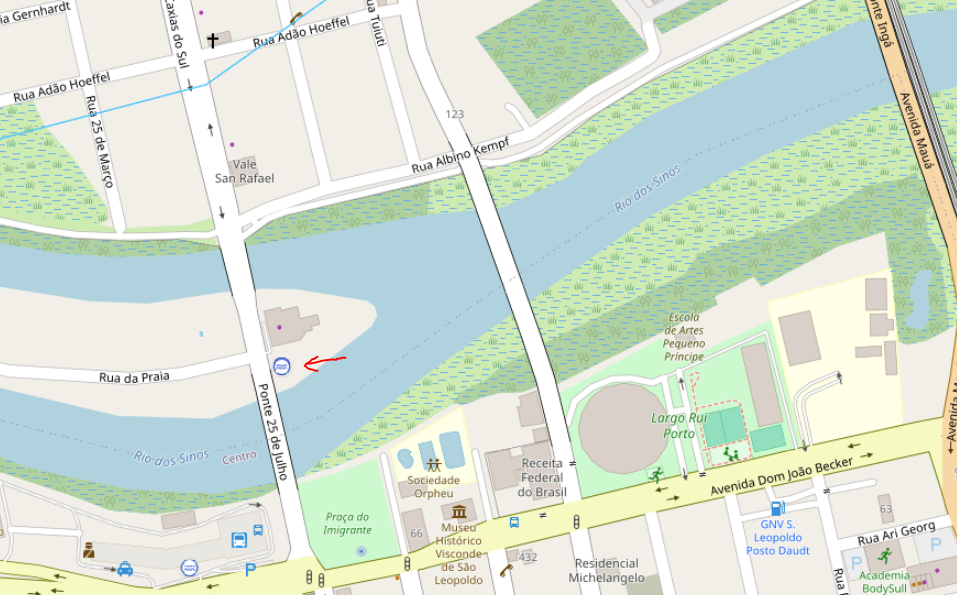

1. Importação de bibliotecas necessárias para todo o projeto

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


2. Carregamento dos dados.
   
O dataset é oriundo da estação cujo código de idenficação é 87382000.Possui as colunas data, hora, chuva, nível e vazão.

Vamos selecionar apenas a coluda data e hora ( fundir em uma unica 'datetime') e a coluna 'Nivel(cm)'.

Finalmente converter dados para número, forçando erros para NaN
 

In [2]:
# Carregamento dos dados
import pandas as pd

# Lê o arquivo Excel com dados de Data, Hora e Nível
df = pd.read_excel('87382000-SAO LEOPOLDO.xlsx')

# Combinação das colunas 'Data' e 'Hora' em uma única coluna datetime
df['datetime'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Hora'].astype(str), errors='coerce')

#  Seleção das colunas relevantes e conversão para numérico
df1 = df[['datetime', 'Nível (cm)']].copy()
df1['Nível (cm)'] = pd.to_numeric(df1['Nível (cm)'], errors='coerce')

# Criação da série temporal com cópia para processamento
serie = df1.set_index('datetime')[['Nível (cm)']].copy()

# Preenchimento de valores faltantes via interpolação e preenchimento alternativo
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_29180\2743230391.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')


3. Estatística descritiva 

C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 230408.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Mean: 193.92
Median: 149.00
Standard deviation: 119.35
Minimum value: 26.00
Maximum value: 811.00
Skewness: 1.23
Kurtosis: 1.43
Shapiro-Wilk normality test: stat=0.878, p=0.000
⚠️ The distribution is likely not normal (p < 0.05)


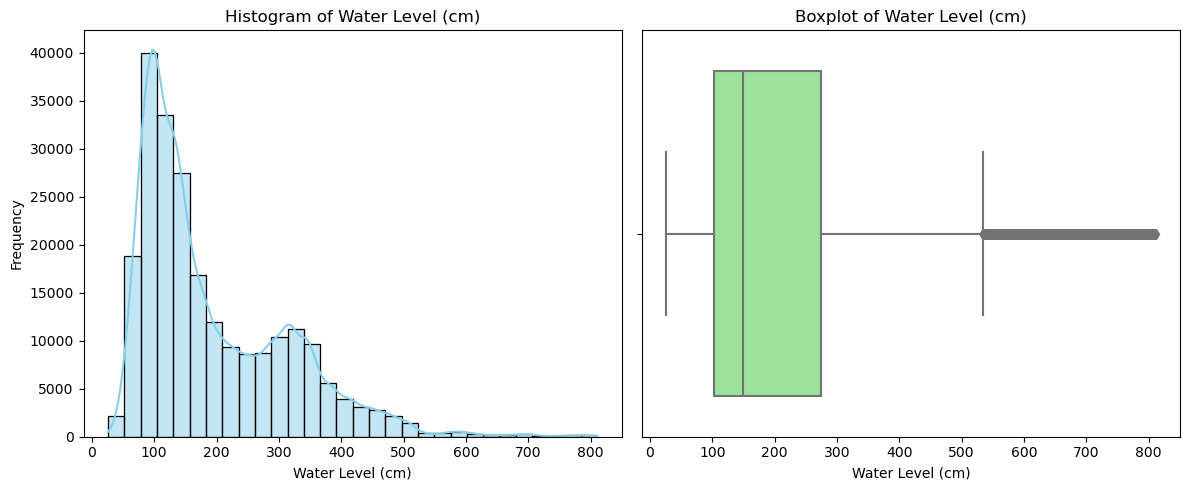

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, shapiro

# Filtrar a coluna sem NaNs
sao_leo_nivel = df1['Nível (cm)'].dropna()

# Estatísticas descritivas
mean = sao_leo_nivel.mean()
median = sao_leo_nivel.median()
std_dev = sao_leo_nivel.std()
minimum = sao_leo_nivel.min()
maximum = sao_leo_nivel.max()
skewness = skew(sao_leo_nivel)
kurt = kurtosis(sao_leo_nivel)
shapiro_stat, shapiro_p = shapiro(sao_leo_nivel)

# Imprimir resultados
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard deviation: {std_dev:.2f}")
print(f"Minimum value: {minimum:.2f}")
print(f"Maximum value: {maximum:.2f}")
print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurt:.2f}")
print(f"Shapiro-Wilk normality test: stat={shapiro_stat:.3f}, p={shapiro_p:.3f}")
if shapiro_p < 0.05:
    print("⚠️ The distribution is likely not normal (p < 0.05)")
else:
    print("✅ The distribution is likely normal (p ≥ 0.05)")

# Visualização - Histograma e Boxplot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(sao_leo_nivel, bins=30, kde=True, color='skyblue')
plt.title("Histogram of Water Level (cm)")
plt.xlabel("Water Level (cm)")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.boxplot(x=sao_leo_nivel, color='lightgreen')
plt.title("Boxplot of Water Level (cm)")
plt.xlabel("Water Level (cm)")

plt.tight_layout()

# Salvar em PDF
plt.savefig("nivel_analysis.pdf", format="pdf")

# Mostrar na tela
plt.show()


4. Análise gráfica da série temporal 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237414 entries, 0 to 237413
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   datetime    237414 non-null  datetime64[ns]
 1   Nível (cm)  230408 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.6 MB
None
             datetime  Nível (cm)
0 2018-08-01 13:15:00       358.0
1 2018-08-01 13:30:00       358.0
2 2018-08-01 13:45:00       357.0
3 2018-08-01 14:00:00       357.0
4 2018-08-01 14:15:00       357.0


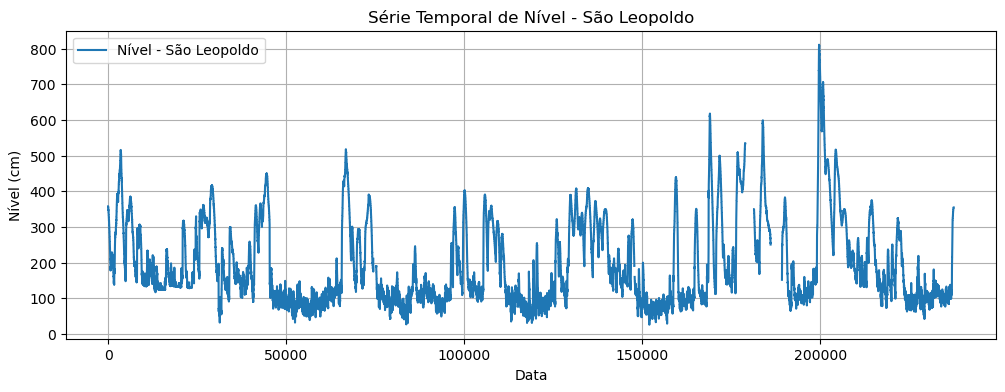

In [7]:
print(df1.info())
print(df1.head())

# 4. Plotar a série temporal de vazão
plt.figure(figsize=(12, 4))
plt.plot(df1.index, df1['Nível (cm)'], label='Nível - São Leopoldo')
plt.title('Série Temporal de Nível - São Leopoldo')
plt.xlabel('Data')
plt.ylabel("Nível (cm)")
plt.grid(True)
plt.legend()
plt.show()


In [13]:
df1

,datetime,Nível (cm)
0,2018-08-01 13:15:00,358.0
1,2018-08-01 13:30:00,358.0
2,2018-08-01 13:45:00,357.0
3,2018-08-01 14:00:00,357.0
4,2018-08-01 14:15:00,357.0
...,...,...
237409,2025-06-01 23:00:00,355.0
237410,2025-06-01 23:15:00,355.0
237411,2025-06-01 23:30:00,355.0
237412,2025-06-01 23:45:00,355.0


In [41]:
df1.isnull().sum().sum()


7006

In [43]:
df1= df1.interpolate(method='linear')


# Treinar modelo  720 min (12h) com cross validation.



C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_29180\980454545.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')



📊 Avaliação via Cross-Validation Temporal:



C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
🔁 Fold 1: MAE = 12.22, RMSE = 16.96, R² = 0.9782


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
🔁 Fold 4: MAE = 11.02, RMSE = 17.01, R² = 0.9856


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
🔁 Fold 5: MAE = 13.73, RMSE = 36.90, R² = 0.9374


C:\Users\AdmPDI\Documents\Conda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1237/1237 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

📉 Evaluation on Fold 5 (includes the flood period):
MAE = 20.31, RMSE = 26.48, R² = 0.9677


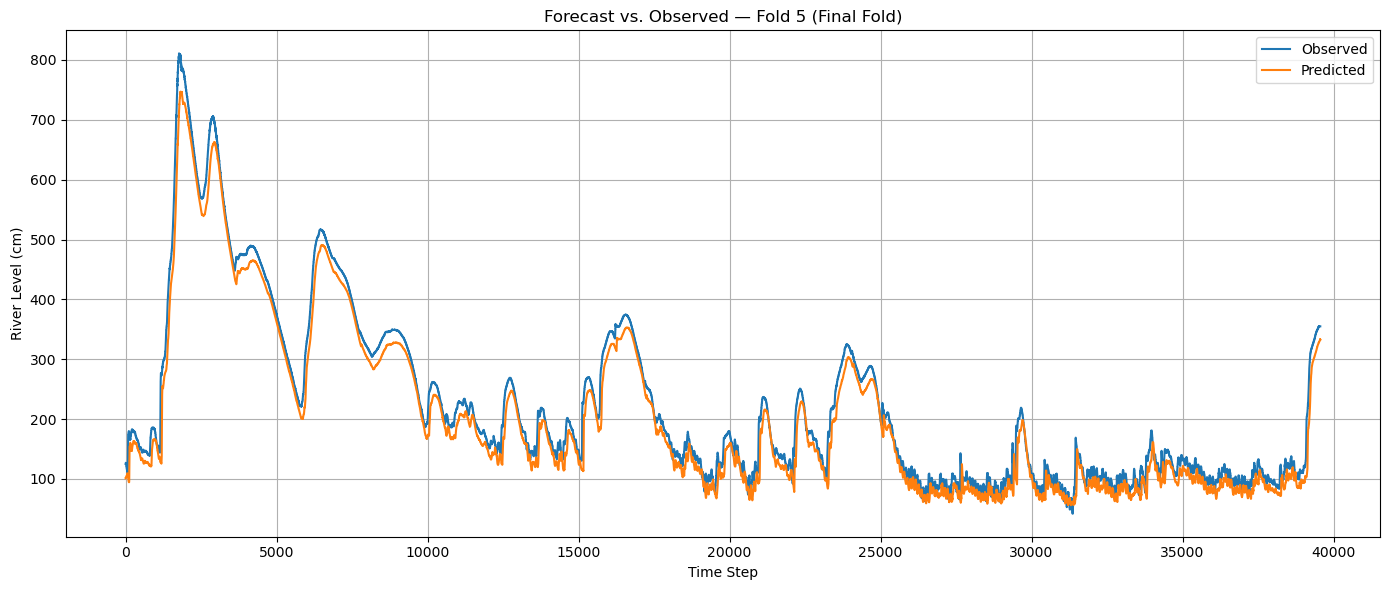

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ====================================
# 1. Pré-processamento
# ====================================
serie = df1[['Nível (cm)']].copy()
serie['Nível (cm)'] = serie['Nível (cm)'].interpolate(method='linear')
serie['Nível (cm)'] = serie['Nível (cm)'].fillna(method='ffill').fillna(method='bfill')

janela = 10
atraso = 48  # 12 horas
valores = serie.values

def cria_janelas(series, janela=10, atraso=48):
    X, y = [], []
    for i in range(len(series) - janela - atraso):
        X.append(series[i:i+janela])
        y.append(series[i+janela+atraso-1])
    return np.array(X), np.array(y)

X_all, y_all = cria_janelas(valores, janela, atraso)

# ====================================
# 2. Cross-validation temporal
# ====================================
tscv = TimeSeriesSplit(n_splits=5)
print("\n📊 Avaliação via Cross-Validation Temporal:\n")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    scaler = MinMaxScaler()
    
    X_train_raw = X_all[train_idx]
    y_train_raw = y_all[train_idx]
    X_test_raw = X_all[test_idx]
    y_test_raw = y_all[test_idx]
    
    # Normalização
    X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
    y_train = scaler.transform(y_train_raw.reshape(-1, 1))
    X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
    y_test = scaler.transform(y_test_raw.reshape(-1, 1))

    # EarlyStopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Modelo com Dropout
    model = Sequential([
        LSTM(50, activation='tanh', dropout=0.0, recurrent_dropout=0.0, input_shape=(janela, 1)),
        Dropout(0.0),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=30, batch_size=32,
              validation_split=0.1, callbacks=[early_stop], verbose=0)

    y_pred_scaled = model.predict(X_test)
    y_pred_inv = scaler.inverse_transform(y_pred_scaled)
    y_test_inv = scaler.inverse_transform(y_test)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    r2 = r2_score(y_test_inv, y_pred_inv)

    print(f"🔁 Fold {fold+1}: MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² = {r2:.4f}")

# ====================================
# 3. Plot do desempenho no Fold 5
# ====================================
# Repete a última iteração do loop para capturar o Fold 5
fold = 4  # fold 5 → índice 4
train_idx, test_idx = list(tscv.split(X_all))[fold]

scaler = MinMaxScaler()

X_train_raw = X_all[train_idx]
y_train_raw = y_all[train_idx]
X_test_raw = X_all[test_idx]
y_test_raw = y_all[test_idx]

# Normalização
X_train = scaler.fit_transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
y_train = scaler.transform(y_train_raw.reshape(-1, 1))
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw.reshape(-1, 1))

# Treinamento do modelo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = Sequential([
    LSTM(50, activation='tanh', dropout=0.1, recurrent_dropout=0.1, input_shape=(janela, 1)),
    Dropout(0.1),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=30, batch_size=32,
          validation_split=0.1, callbacks=[early_stop], verbose=0)

# Previsão
y_pred_scaled = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred_scaled)
y_test_inv = scaler.inverse_transform(y_test)

# Métricas
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("\n📉 Evaluation on Fold 5 (includes the flood period):")
print(f"MAE = {mae:.2f}, RMSE = {rmse:.2f}, R² = {r2:.4f}")

# Gráfico
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label="Observed")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Forecast vs. Observed — Fold 5 (Final Fold)")
plt.xlabel("Time Step")
plt.ylabel("River Level (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


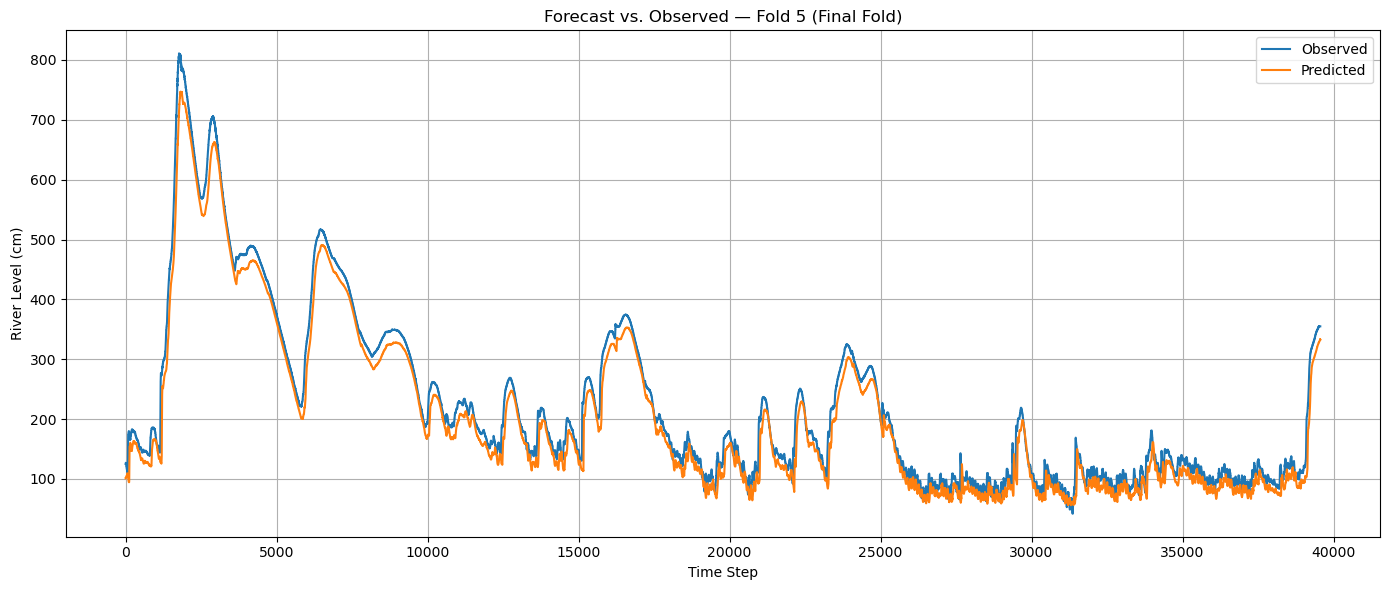

In [27]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_inv, label="Observed")
plt.plot(y_pred_inv, label="Predicted")
plt.title("Forecast vs. Observed — Fold 5 (Final Fold)")
plt.xlabel("Time Step")
plt.ylabel("River Level (cm)")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Export to PDF
plt.savefig("fold5_forecast.pdf", format='pdf', dpi=300)

# Show plot
plt.show()


In [21]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    print(f"Fold {fold+1}:")
    print(f"  Treino: {len(train_idx)} amostras")
    print(f"  Teste : {len(test_idx)} amostras\n")


Fold 1:
  Treino: 39561 amostras
  Teste : 39559 amostras

Fold 2:
  Treino: 79120 amostras
  Teste : 39559 amostras

Fold 3:
  Treino: 118679 amostras
  Teste : 39559 amostras

Fold 4:
  Treino: 158238 amostras
  Teste : 39559 amostras

Fold 5:
  Treino: 197797 amostras
  Teste : 39559 amostras



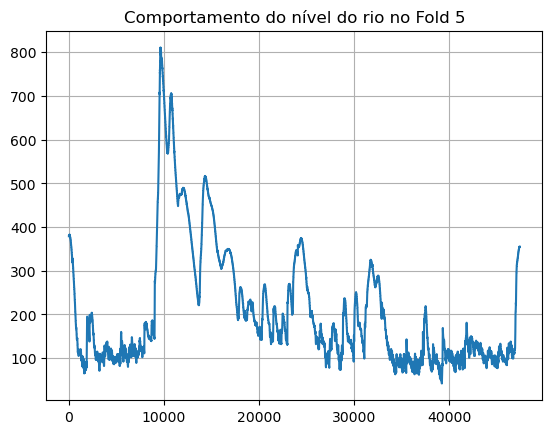

In [23]:
plt.plot(y_test_raw, label='Valores reais Fold 5')
plt.title("Comportamento do nível do rio no Fold 5")
plt.grid(True)
plt.show()


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_18000\3370427563.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


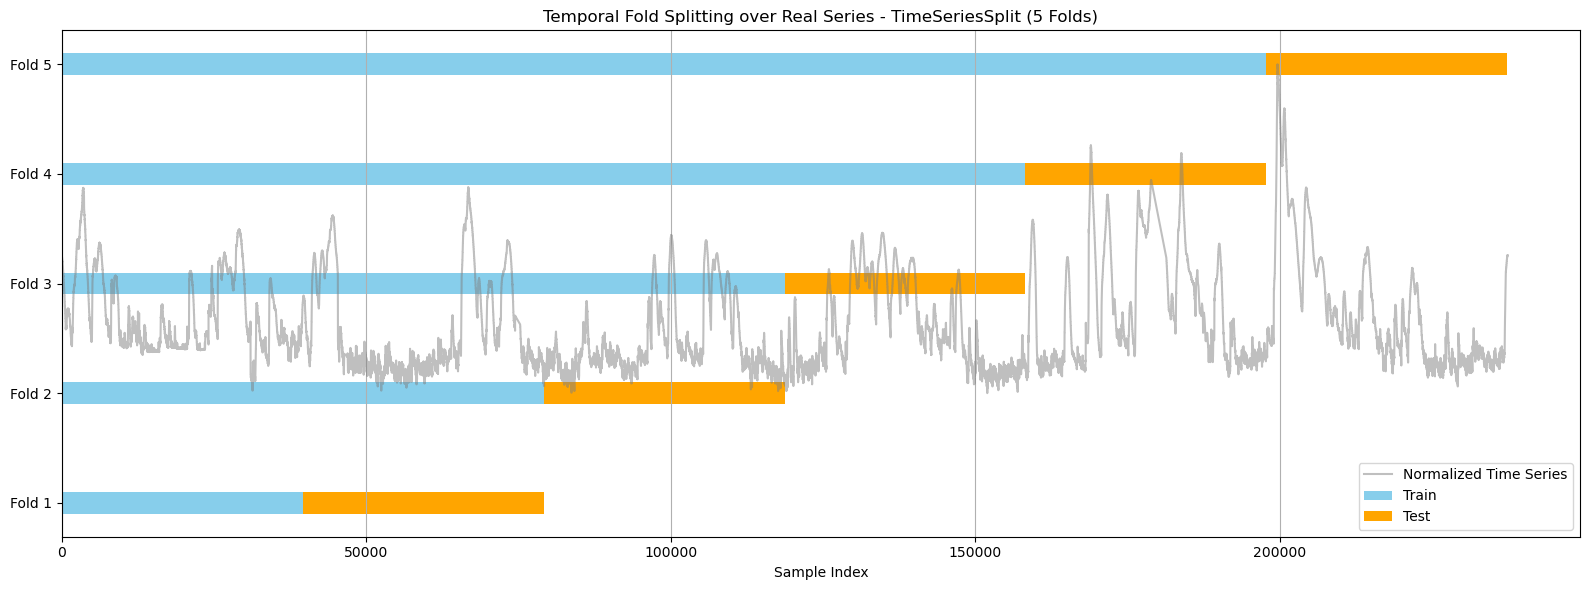

In [79]:
import matplotlib.pyplot as plt

# Garantir que 'Nível (cm)' esteja limpo
serie_plot = df1['Nível (cm)'].copy()
serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

# Normalização e escalonamento para visualização
serie_plot = (serie_plot - serie_plot.min()) / (serie_plot.max() - serie_plot.min())
serie_plot_scaled = serie_plot * 3 + 1

# Recalcula n com base na série final
n = len(serie_plot)

# Folds
fold_size = 39559
train_sizes = [39561, 79120, 118679, 158238, 197797]
test_starts = train_sizes
test_ends = [min(start + fold_size, n) for start in test_starts]

# Gráfico
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(range(n), serie_plot_scaled.values, color='grey', alpha=0.5, label='Normalized Time Series')

for i, (train_end, test_start, test_end) in enumerate(zip(train_sizes, test_starts, test_ends)):
    ax.barh(y=i, width=train_end, left=0, height=0.2, color='skyblue', label='Train' if i == 0 else "")
    ax.barh(y=i, width=test_end - test_start, left=test_start, height=0.2, color='orange', label='Test' if i == 0 else "")

ax.set_yticks(range(len(train_sizes)))
ax.set_yticklabels([f'Fold {i+1}' for i in range(len(train_sizes))])
ax.set_xlabel("Sample Index")
ax.set_title("Temporal Fold Splitting over Real Series - TimeSeriesSplit (5 Folds)")
ax.legend(loc='lower right')
ax.grid(True, axis='x')
plt.tight_layout()

# ✅ Exportar corretamente em Jupyter
fig.savefig("fold_split_plot.pdf", format='pdf', dpi=300)
plt.show()


C:\Users\AdmPDI\AppData\Local\Temp\ipykernel_29180\1910123582.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')


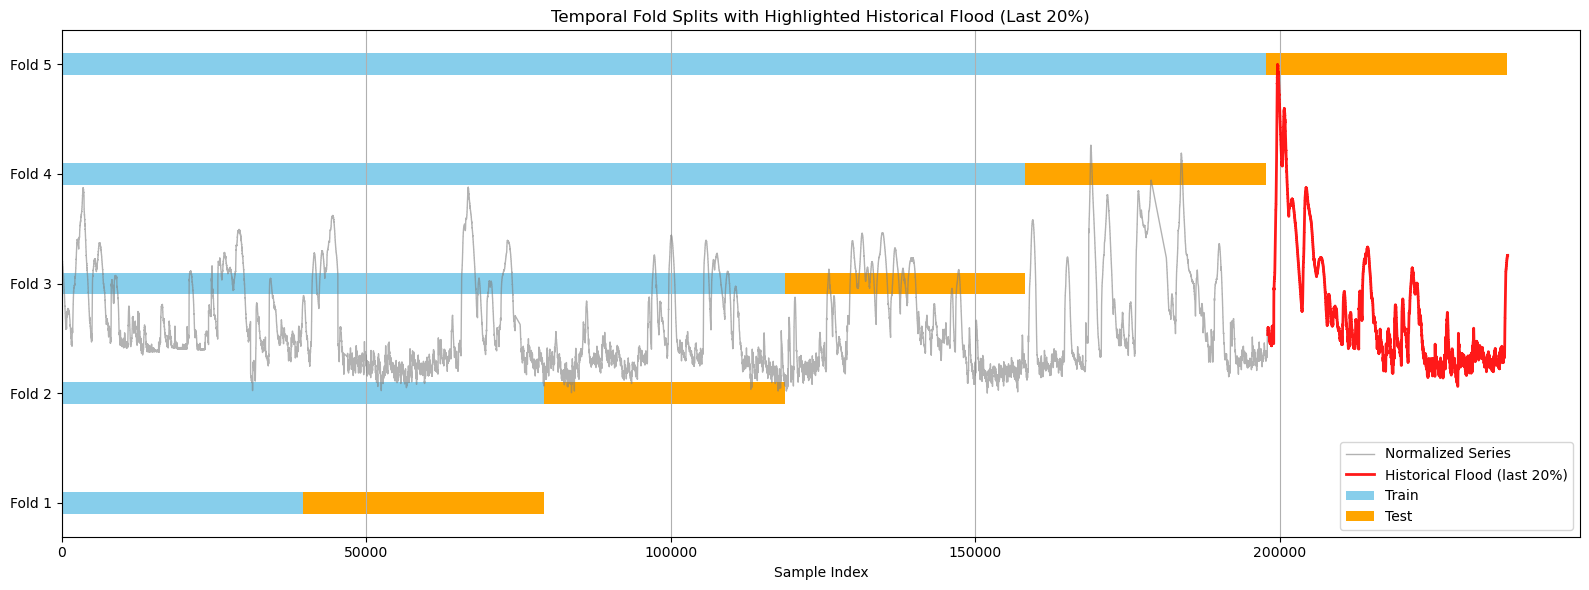

In [23]:
import matplotlib.pyplot as plt

# Ensure 'Nível (cm)' is clean
serie_plot = df1['Nível (cm)'].copy()
serie_plot = serie_plot.interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

# Normalization and scaling for visualization
serie_plot = (serie_plot - serie_plot.min()) / (serie_plot.max() - serie_plot.min())
serie_plot_scaled = serie_plot * 3 + 1  # scaled for better visualization above bars

# Recalculate n based on final series
n = len(serie_plot)
anomaly_limit = int(n * 0.834)  # last 20% as historical flood

# Fold settings
fold_size = 39559
train_sizes = [39561, 79120, 118679, 158238, 197797]
test_starts = train_sizes
test_ends = [min(start + fold_size, n) for start in test_starts]

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

# Normalized series – regular part (80%)
ax.plot(range(0, anomaly_limit), serie_plot_scaled.values[:anomaly_limit],
        color='grey', alpha=0.6, linewidth=1, label='Normalized Series')

# Anomalous part (last 20%) – historical flood
ax.plot(range(anomaly_limit, n), serie_plot_scaled.values[anomaly_limit:],
        color='red', alpha=0.9, linewidth=2, label='Historical Flood (last 20%)')

# Horizontal bars per fold
for i, (train_end, test_start, test_end) in enumerate(zip(train_sizes, test_starts, test_ends)):
    ax.barh(y=i, width=train_end, left=0, height=0.2, color='skyblue', label='Train' if i == 0 else "")
    ax.barh(y=i, width=test_end - test_start, left=test_start, height=0.2, color='orange', label='Test' if i == 0 else "")

# Axes and labels
ax.set_yticks(range(len(train_sizes)))
ax.set_yticklabels([f'Fold {i+1}' for i in range(len(train_sizes))])
ax.set_xlabel("Sample Index")
ax.set_title("Temporal Fold Splits with Highlighted Historical Flood (Last 20%)")
ax.legend(loc='lower right')
ax.grid(True, axis='x')
plt.tight_layout()

# Export as PDF
fig.savefig("fold_split_plot_with_flood.pdf", format='pdf', dpi=300)
plt.show()


# APU

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

# --- 2. Carrega modelo e scaler ---
modelo = tf.keras.models.load_model("modelo_720min.h5", compile=False)
scaler = joblib.load("scaler_720min.save")

# --- 3. Carrega dados e prepara série ---
df = pd.read_excel("87382000-SAO LEOPOLDO.xlsx")
df['datetime'] = pd.to_datetime(df['Data'].astype(str) + ' ' + df['Hora'].astype(str))
df = df.set_index('datetime')
df['Nível (cm)'] = pd.to_numeric(df['Nível (cm)'], errors='coerce')
serie = df[['Nível (cm)']].interpolate(method='linear').fillna(method='ffill')

# --- 4. Cria janelas para teste ---
def cria_janelas(series, janela=10, atraso=48):
    X, y = [], []
    for i in range(len(series) - janela - atraso):
        X.append(series[i:i+janela])
        y.append(series[i+janela+atraso-1])
    return np.array(X), np.array(y)

janela = 10
atraso = 32
X_raw, y_raw = cria_janelas(serie.values, janela, atraso)
div = int(len(X_raw) * 0.8)
X_test_raw = X_raw[div:div+10000]   # <== reduzido para 300 valores
y_test_raw = y_raw[div:div+10000]
datas = serie.index[div + janela + atraso - 1:][:10000]

# --- 5. Normaliza dados ---
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_test = scaler.transform(y_test_raw.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test).flatten()

# --- 6. Predição e cálculo de SE, RE ---
y_pred_scaled = modelo.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred_scaled).flatten()
residuos = y_pred_inv - y_test_inv
SE = np.mean(residuos)
RE = np.std(residuos - SE)

# --- 7. Cálculo de incertezas APU ---
u_x_seq = np.array([2]*10)
u_y = 2
k = 2
preds_scaled, incs = [], []

for i in range(len(X_test)):
    res = apu_uncertainty_lstm_aprimorado(modelo, X_test[i], u_x_seq, SE, RE, u_y, k)
    preds_scaled.append(res['y_pred'])
    incs.append(res['U'])


# Desnormaliza previsões
preds_inv = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()

In [ ]:
import matplotlib.pyplot as plt

# --- 8. Gráfico ---
fig, ax = plt.subplots(figsize=(14, 6))  # CORREÇÃO: fig é atribuído aqui
ax.plot(datas, y_test_inv, label="Valor Real", color='black', linewidth=1)
ax.plot(datas, preds_inv, label="Previsão", color='blue', linewidth=1)
ax.fill_between(datas, preds_inv - incs, preds_inv + incs, color='blue', alpha=0.3, label='±U (APU)')
ax.legend()
ax.set_title("Previsão com Incerteza APU (LSTM)")
ax.set_xlabel("Data")
ax.set_ylabel("Nível (cm)")
plt.xticks(rotation=45)
ax.grid(True)
fig.tight_layout()

# Mostrar na tela
plt.show()

# Exportar como PDF
fig.savefig("apu_lstm_previsao.pdf", format='pdf', dpi=300)


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

# Linha real (preta, fina)
fig.add_trace(go.Scatter(
    x=datas,
    y=y_test_inv.flatten(),
    mode='lines',
    name='Real',
    line=dict(color='black', width=1, dash='dot')  # pontilhada e leve
))

# Linha de previsão (azul, fina)
fig.add_trace(go.Scatter(
    x=datas,
    y=preds_inv,
    mode='lines',
    name='Previsão',
    line=dict(color='blue', width=1)  # linha contínua, leve
))

# Banda superior
fig.add_trace(go.Scatter(
    x=datas,
    y=preds_inv + incs,
    mode='lines',
    line=dict(width=0),
    showlegend=False
))

# Banda inferior com preenchimento
fig.add_trace(go.Scatter(
    x=datas,
    y=preds_inv - incs,
    mode='lines',
    name='±U (Incerteza-95.45%)',
    fill='tonexty',
    fillcolor='rgba(0, 0, 255, 0.15)',
    line=dict(width=0),
    showlegend=True
))

# Layout
fig.update_layout(
    title="Previsão do Nível Rio dos Sinos -São Leopoldo com Incerteza (APU) ",
    xaxis_title="Data",
    yaxis_title="Nível (cm)",
    hovermode='x unified',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    font=dict(size=12),
    margin=dict(l=40, r=40, t=40, b=40)
)

# Mostrar o gráfico interativo
fig.show()

# Salvar como PDF
fig.write_image("apu.pdf", format='pdf')  # requer pacote kaleido instalado
